In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("bmw.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nColumn names:")
print(data.columns)


First 5 rows:
       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  

Dataset shape:
(10781, 9)

Column names:
Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')


In [3]:
print("\nStatistical Summary:")
print(data.describe())



Statistical Summary:
               year          price        mileage           tax           mpg  \
count  10781.000000   10781.000000   10781.000000  10781.000000  10781.000000   
mean    2017.078935   22733.408867   25496.986550    131.702068     56.399035   
std        2.349038   11415.528189   25143.192559     61.510755     31.336958   
min     1996.000000    1200.000000       1.000000      0.000000      5.500000   
25%     2016.000000   14950.000000    5529.000000    135.000000     45.600000   
50%     2017.000000   20462.000000   18347.000000    145.000000     53.300000   
75%     2019.000000   27940.000000   38206.000000    145.000000     62.800000   
max     2020.000000  123456.000000  214000.000000    580.000000    470.800000   

         engineSize  
count  10781.000000  
mean       2.167767  
std        0.552054  
min        0.000000  
25%        2.000000  
50%        2.000000  
75%        2.000000  
max        6.600000  


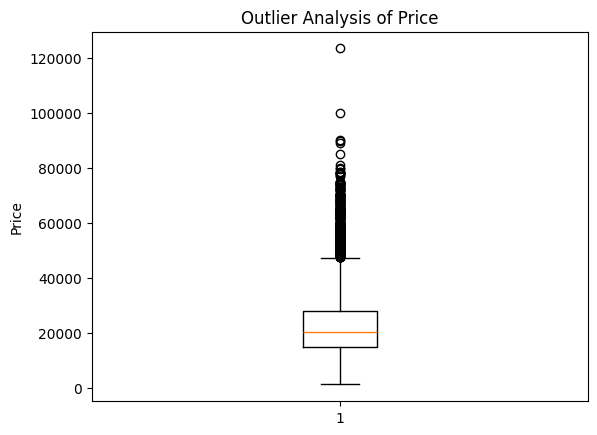

In [4]:
plt.boxplot(data['price'])
plt.title("Outlier Analysis of Price")
plt.ylabel("Price")
plt.show()


In [5]:
X = data.drop('fuelType', axis=1)
y = data['fuelType']

print("Independent variables:")
print(X.head())

print("\nDependent variable:")
print(y.head())


Independent variables:
       model  year  price transmission  mileage  tax   mpg  engineSize
0   5 Series  2014  11200    Automatic    67068  125  57.6         2.0
1   6 Series  2018  27000    Automatic    14827  145  42.8         2.0
2   5 Series  2016  16000    Automatic    62794  160  51.4         3.0
3   1 Series  2017  12750    Automatic    26676  145  72.4         1.5
4   7 Series  2014  14500    Automatic    39554  160  50.4         3.0

Dependent variable:
0    Diesel
1    Petrol
2    Diesel
3    Diesel
4    Diesel
Name: fuelType, dtype: object


In [6]:
print("\nMissing values before handling:")
print(data.isnull().sum())

data.fillna(data.mean(numeric_only=True), inplace=True)

print("\nMissing values after handling:")
print(data.isnull().sum())



Missing values before handling:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Missing values after handling:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['model'] = le.fit_transform(data['model'])
data['transmission'] = le.fit_transform(data['transmission'])
data['fuelType'] = le.fit_transform(data['fuelType'])


In [8]:
X = data.drop('fuelType', axis=1)
y = data['fuelType']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (8624, 8)
Testing data shape: (2157, 8)


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN Accuracy:")
print(accuracy_score(y_test, y_pred_knn))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))



KNN Accuracy:
0.6536856745479833

KNN Confusion Matrix:
[[1139    4    0  229]
 [  51    1    0   12]
 [   7    0    0    0]
 [ 439    5    0  270]]


In [11]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("\nNaive Bayes Accuracy:")
print(accuracy_score(y_test, y_pred_nb))

print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))



Naive Bayes Accuracy:
0.8215113583681039

Naive Bayes Confusion Matrix:
[[1196    0    1    0  175]
 [   0    0    0    0    0]
 [   5    9   39    9    2]
 [   0    1    0    6    0]
 [ 183    0    0    0  531]]
